# 06. 최종 모델 산출물 4종 — 클래스별 성능 · SHAP · 혼동행렬 · 임계값 곡선

3차 전처리 58피처로 학습한 LightGBM 13-class 모델의 성능을 네 각도에서 본다.
**Macro-F1 0.6138** 이 어떻게 구성되는지, 어느 유형이 무너지는지를 특정하는 것이 목적이다.

> **출처** — `원본/최종_3차_통합분석.ipynb` (코드 셀 **1개**, 29,946자)
>
> 원본은 `RUN_PART1`~`RUN_PART4` 플래그로 5개 파트를 한 셀에서 켜고 끄는 구조였다.
> 이 저장소는 그 플래그 경계를 그대로 살려 파트별 노트북으로 분리하고,
> **원본 실행 출력(표·그래프)을 해당 셀에 그대로 옮겨 붙였다.**
> 따라서 데이터가 없어도 결과를 볼 수 있고, 데이터가 있으면 그대로 재실행된다.



### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/X_tr.parquet` · `X_va.parquet` · `y_tr.parquet` · `y_va.parquet` (**3차 전처리**) |
| 형상 | train `(96,140 × 58)` / valid `(23,860 × 58)` |
| 정상 클래스 | `12` (= `m`) |
| 모델 | `LGBMClassifier` · `n_estimators=300` · `class_weight="balanced"` · `random_state=42` |
| 학습 시간 | 약 13초 (4스레드) |

> `data/` 는 용량(141MB) 때문에 저장소에 포함하지 않았다 — `data/README.md` 참고.
> 아래 셀의 출력은 **원본 실행 결과 그대로**다.

> ⚠️ 원본의 `if RUN_PARTn:` 가드는 제거하고 들여쓰기를 풀었다.
> 파트별 노트북이므로 그 파트는 항상 실행된다 — **로직은 원본과 동일**하다.


## 0. 공통 설정 · 데이터 로드 · 모델 학습

다섯 개 노트북이 모두 이 블록으로 시작한다. 원본 통합 셀의 `[0]` 구획이다.


In [ ]:
# [0] 설정 · 데이터 로드 · 모델 학습 (여기부터 순서대로 실행)
import warnings, time, logging
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===== 설정 =====
DATA_DIR = "../../data"        # 3차 전처리 parquet 폴더 (원본 실행 경로:
                               #   /mnt/c/Users/dkstj/Desktop/test_uv/3차 전처리 파일)
SEED = 42
LGBM_THREADS = 4
N_ESTIMATORS = 300             # 느리면 150~200 (수치가 달라짐)

RUN_PART1 = True               # 산출물 4종
RUN_COMPARE = True             # 모델 비교(한방 기본/임계값 · 2계층 기본/임계값) — 2계층 학습 포함
RUN_PART2 = True               # 비용기반 임계값
RUN_PART3 = True               # 규칙기반 + ML 결합
RUN_PART4 = True               # 생성 AI 합성데이터 증강 비교 (느림: sdv 필요)

LEAK_COLS = ["is_fraud", "fraud_type", "label", "y"]      # 정답 라벨 자동 제거
LOOKAHEAD_SUSPECT = ["Account_one_month_max_amount", "Account_one_month_std_dev",
                     "Account_dawn_one_month_max_amount", "Account_dawn_one_month_std_dev",
                     "Amount_vs_monthly_max_ratio"]        # 남아 있으면 경고만

# 비용 가정 (팀 합의값으로 교체)
FN_COST = 17_000_000
FP_SCENARIOS = {"A (FP 5k)": 5_000, "B (FP 10k)": 10_000, "C (FP 50k)": 50_000}
MACRO_MIN = 0.60               # 최종 채택 조건: Macro-F1 최소기준선
AMOUNT_COL = "Transaction_Amount_abs"

# 임계값 격자
THR_FULL = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
            0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]
THR_BARS = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02, 0.03]
THR_COLLAPSE = [0.0, 0.00001, 0.00002, 0.00005, 0.0001, 0.00015, 0.0002]

SHAP_SAMPLE = 2000
TOP_FEATURES = 15

# [3] 하이브리드
RULE_MIN_SUPPORT = 15
PRECISION_SCAN = [0.85, 0.70, 0.50, 0.30]
CONT_Q_HI, CONT_Q_LO = [0.90, 0.95, 0.99], [0.01, 0.05, 0.10]
VERIFIED_COMPOSITES = ["large_deposit_and_remote_control", "unused_terminal_and_internet",
                       "limit_check_then_transfer", "suspended_recipient_and_withdrawal",
                       "new_recipient_and_large_amount", "weak_signal_composite_score"]
BOOST_WEIGHT = 0.30

# [4] 증강
TRAIN_SUBSAMPLE_NORMAL = 20000
TARGET_PER_CLASS = 500
GEN_EPOCHS = 300

LGBM_PARAMS = dict(n_estimators=N_ESTIMATORS, learning_rate=0.05, num_leaves=31,
                   subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                   random_state=SEED, n_jobs=LGBM_THREADS, verbose=-1)
lab = lambda i: chr(ord("a") + int(i))
np.random.seed(SEED)

In [ ]:
# ===== 표시 유틸 =====
def _setup_plt():
    import matplotlib
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    import matplotlib.pyplot as plt
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    return plt


def _table(df, caption=""):
    """VS Code/Jupyter면 표로 렌더링(출력 잘림 방지), 아니면 텍스트."""
    if caption:
        print(f"\n[{caption}]")
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            from IPython.display import display
            display(df); return
    except Exception:
        pass
    print(df.to_string(index=False))


def _head(title):
    print("\n" + "=" * 74); print(f" {title}"); print("=" * 74)

In [ ]:
# ===== 데이터 로드 =====
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

_d = Path(DATA_DIR)
X_tr = pd.read_parquet(_d / "X_tr.parquet").reset_index(drop=True)
X_va = pd.read_parquet(_d / "X_va.parquet").reset_index(drop=True)
y_tr = pd.read_parquet(_d / "y_tr.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
y_va = pd.read_parquet(_d / "y_va.parquet").iloc[:, 0].astype(int).reset_index(drop=True)

_drop = [c for c in X_tr.columns if c.lower() in [s.lower() for s in LEAK_COLS]]
if _drop:
    print(f"[누수 제거] 정답 라벨 {_drop} 자동 제외")
    X_tr = X_tr.drop(columns=_drop); X_va = X_va.drop(columns=_drop)
_rest = [c for c in LOOKAHEAD_SUSPECT if c in X_tr.columns]
if _rest:
    print(f"[경고] look-ahead 의심 피처 잔존: {_rest}")
    print("       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요")

normal_idx = int(y_tr.value_counts().idxmax())
classes = sorted(y_tr.unique()); labels = [lab(c) for c in classes]
fcols = list(X_tr.columns)
amount = X_va[AMOUNT_COL].values.copy() if AMOUNT_COL in X_va.columns else None
basis = f"{X_tr.shape[1]} features | valid {len(y_va):,} rows (hold-out)"
basis_kr = f"피처 {X_tr.shape[1]}개 · valid 홀드아웃 {len(y_va):,}행 · 트리 {N_ESTIMATORS}"

_head(f"3차 전처리 통합 분석 — {basis_kr}")
print(f"[데이터] train {X_tr.shape} / valid {X_va.shape} | 정상={normal_idx}({lab(normal_idx)})")


# ===== 모델 학습 (1회, 전 파트 공유) =====
print("\n[학습] LightGBM 13-class ...")
_t = time.time()
model = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
pred = model.predict(X_va)
macro = f1_score(y_va, pred, average="macro")
print(f"[검증] {round(time.time()-_t,1)}s | Macro-F1={macro:.4f} | "
      f"Weighted-F1={f1_score(y_va, pred, average='weighted'):.4f} | "
      f"Accuracy={accuracy_score(y_va, pred):.4f}")
print("  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단")

rep = classification_report(y_va, pred, labels=classes, target_names=labels,
                            output_dict=True, zero_division=0)
proba = model.predict_proba(X_va)
_cls = list(model.classes_); _npos = _cls.index(normal_idx)
risk = 1.0 - proba[:, _npos]                       # 위험점수 = 1 − P(정상)
_fp = proba.copy(); _fp[:, _npos] = -1.0
best_fraud = np.asarray(_cls)[_fp.argmax(axis=1)]  # 정상 제외 최고확률 유형
y_arr = np.asarray(y_va); yb = (y_arr != normal_idx)

[경고] look-ahead 의심 피처 잔존: ['Account_one_month_max_amount', 'Account_one_month_std_dev', 'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev', 'Amount_vs_monthly_max_ratio']
       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요

 3차 전처리 통합 분석 — 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
[데이터] train (96140, 58) / valid (23860, 58) | 정상=12(m)

[학습] LightGBM 13-class ...
[검증] 13.3s | Macro-F1=0.6138 | Weighted-F1=0.9942 | Accuracy=0.9949
  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단


위험점수 `risk = 1 − P(정상 m)` 기준 임계값 판정 헬퍼. 임계값을 쓰는 파트에서 공통으로 사용한다.


In [ ]:
def thr_predict(thr):
    """위험점수 ≥ thr → 사기(최고확률 유형), 아니면 정상."""
    p = np.full(len(y_arr), normal_idx); m = risk >= thr
    p[m] = best_fraud[m]; return p, m


def thr_scan(grid):
    rows = []
    for t in grid:
        p, m = thr_predict(t)
        fn = int((yb & ~m).sum()); fp = int((~yb & m).sum())
        r = dict(thr=t, macro=round(f1_score(y_arr, p, average="macro"), 4), FN=fn, FP=fp)
        for k, v in FP_SCENARIOS.items():
            r[k] = round((fn * FN_COST + fp * v) / 1e8, 3)
        if amount is not None:
            r["FN실제금액(억)"] = round(float(amount[yb & ~m].sum()) / 1e8, 2)
            r["FN고정값(억)"] = round(fn * FN_COST / 1e8, 2)
        rows.append(r)
    return pd.DataFrame(rows)

## 1. 산출물 4종


In [ ]:
_head("[1] 산출물 4종")
plt = _setup_plt()


 [1] 산출물 4종


### ① 클래스별 성능 — 어느 유형이 무너지는가

정상 `m` 을 뺀 사기 12유형만 본다. `m` 은 F1 0.9987 이라 함께 그리면 나머지가 안 보인다.


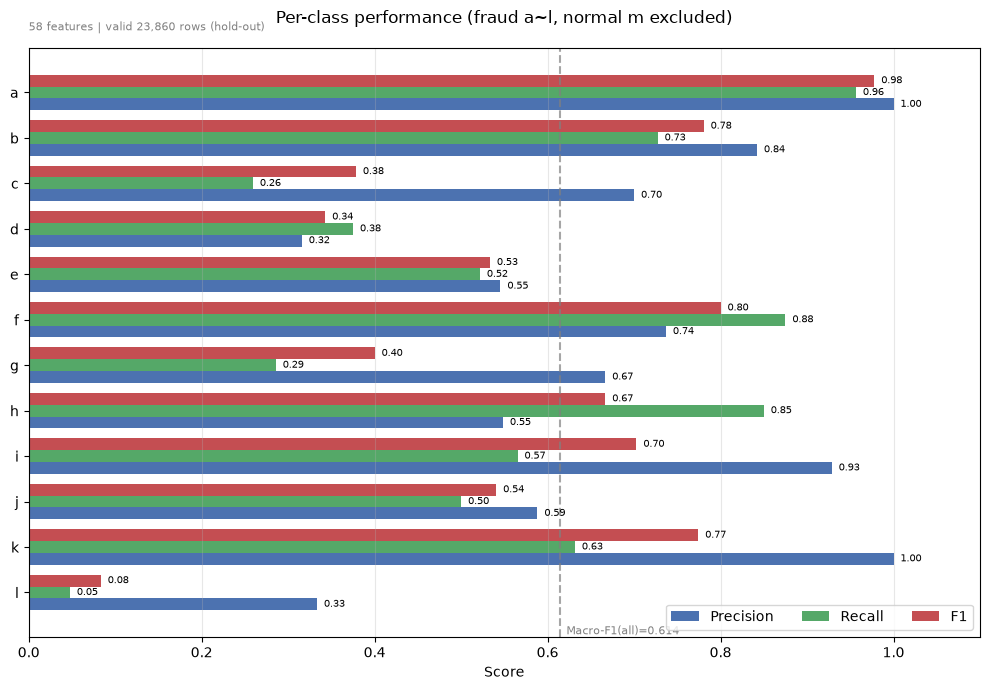


[① 클래스별 성능 표]


,클래스,precision,recall,f1,support
0,a,1.0000,0.9565,0.9778,23
1,b,0.8421,0.7273,0.7805,22
2,c,0.7000,0.2593,0.3784,27
3,d,0.3158,0.3750,0.3429,16
4,e,0.5455,0.5217,0.5333,23
5,f,0.7368,0.8750,0.8000,16
6,g,0.6667,0.2857,0.4000,28
7,h,0.5484,0.8500,0.6667,20
8,i,0.9286,0.5652,0.7027,23
9,j,0.5882,0.5000,0.5405,20


  [약한 유형 Top3] l(0.08), d(0.34), c(0.38)  ← 개선 우선


In [ ]:
# ① 클래스별 성능
fl = [l for l in labels if l != lab(normal_idx)]
P = [rep[l]["precision"] for l in fl]; R = [rep[l]["recall"] for l in fl]
F = [rep[l]["f1-score"] for l in fl]
yy = np.arange(len(fl)); h = 0.26
fig, ax = plt.subplots(figsize=(10, 7))
gs = [ax.barh(yy + h, P, h, label="Precision", color="#4C72B0"),
      ax.barh(yy,     R, h, label="Recall",    color="#55A868"),
      ax.barh(yy - h, F, h, label="F1",        color="#C44E52")]
ax.set_yticks(yy); ax.set_yticklabels(fl); ax.invert_yaxis()
ax.set_xlim(0, 1.10); ax.set_xlabel("Score")
ax.set_title("Per-class performance (fraud a~l, normal m excluded)", pad=18)
_m = rep["macro avg"]["f1-score"]; ax.axvline(_m, ls="--", color="gray", alpha=.7)
ax.text(_m + 0.008, ax.get_ylim()[0], f"Macro-F1(all)={_m:.3f}", color="gray", fontsize=8, va="bottom")
for g in gs:
    for r in g:
        w = r.get_width()
        ax.text(w + 0.008, r.get_y() + r.get_height()/2, f"{w:.2f}", va="center", fontsize=7)
ax.legend(loc="lower right", ncol=3); ax.grid(axis="x", alpha=.3)
ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
fig.tight_layout(); plt.show()

rows = [{"클래스": l, "precision": round(rep[l]["precision"], 4),
         "recall": round(rep[l]["recall"], 4), "f1": round(rep[l]["f1-score"], 4),
         "support": int(rep[l]["support"])} for l in labels]
for k in ["macro avg", "weighted avg"]:
    rows.append({"클래스": k, "precision": round(rep[k]["precision"], 4),
                 "recall": round(rep[k]["recall"], 4), "f1": round(rep[k]["f1-score"], 4),
                 "support": int(rep[k]["support"])})
_table(pd.DataFrame(rows), "① 클래스별 성능 표")
_weak = sorted({l: rep[l]["f1-score"] for l in fl}.items(), key=lambda x: x[1])[:3]
print("  [약한 유형 Top3] " + ", ".join(f"{k}({v:.2f})" for k, v in _weak) + "  ← 개선 우선")

### ② SHAP — 모델이 실제로 무엇을 보는가

EDA 단계의 신호 추정과 모델의 실제 기여도를 대조하는 셀이다.
튜터 피드백(“파생변수 근거가 순환논리 — SHAP/importance 로 뒷받침하라”)에 대한 직접 응답.



[SHAP] TreeExplainer 계산 (표본 2000행) ...


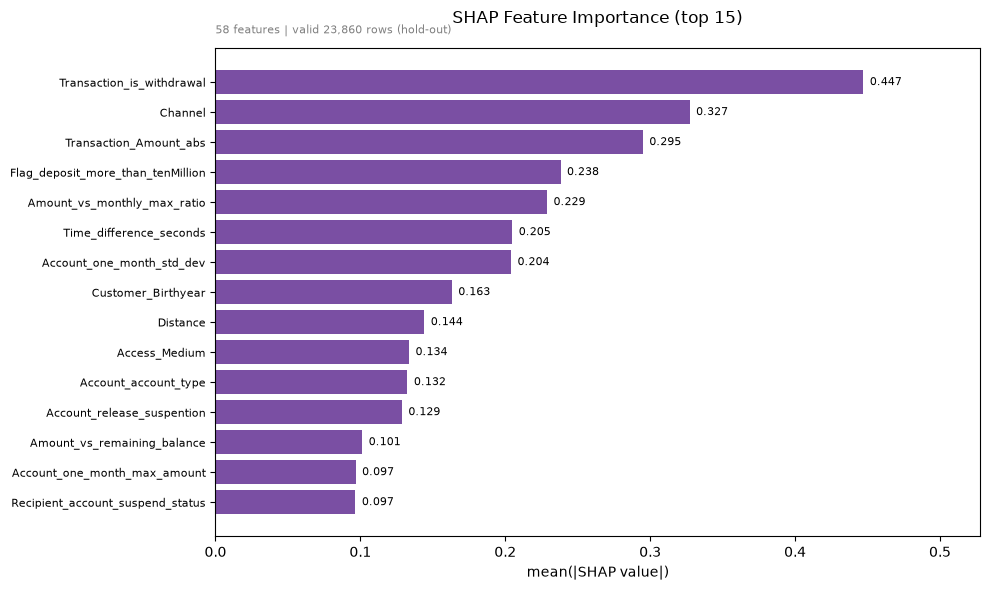


[② SHAP 상위 15 피처 표]


,feature,mean_abs_shap
0,Transaction_is_withdrawal,0.4471
1,Channel,0.3272
2,Transaction_Amount_abs,0.2949
3,Flag_deposit_more_than_tenMillion,0.2381
4,Amount_vs_monthly_max_ratio,0.2288
5,Time_difference_seconds,0.2049
6,Account_one_month_std_dev,0.2040
7,Customer_Birthyear,0.1631
8,Distance,0.1441
9,Access_Medium,0.1336


In [ ]:
# ② SHAP
try:
    import shap
    n = min(SHAP_SAMPLE, len(X_va)); Xs = X_va.sample(n, random_state=SEED)
    print(f"\n[SHAP] TreeExplainer 계산 (표본 {n}행) ...")
    sv = shap.TreeExplainer(model).shap_values(Xs)
    if isinstance(sv, list):
        ma = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    else:
        a = np.abs(np.asarray(sv)); ma = a.mean(axis=(0, 2)) if a.ndim == 3 else a.mean(axis=0)
    order = np.argsort(ma)[::-1][:TOP_FEATURES]
    names = [fcols[i] for i in order][::-1]; vals = ma[order][::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(names)), vals, color="#7A4FA3")
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("mean(|SHAP value|)"); ax.set_xlim(0, max(vals) * 1.18)
    ax.set_title(f"SHAP Feature Importance (top {TOP_FEATURES})", pad=18)
    ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.01, i, f"{v:.3f}", va="center", fontsize=8)
    fig.tight_layout(); plt.show()
    _table(pd.DataFrame({"feature": [fcols[i] for i in order],
                         "mean_abs_shap": [round(float(ma[i]), 4) for i in order]}),
           f"② SHAP 상위 {TOP_FEATURES} 피처 표")
except Exception as e:
    print(f"[SHAP 건너뜀] {e}  (pip install shap)")

### ③ 혼동행렬 — 무엇을 무엇으로 헷갈리는가

행 정규화(`normalize="true"`). 정상 흡수율과 유형 간 혼동을 함께 본다.


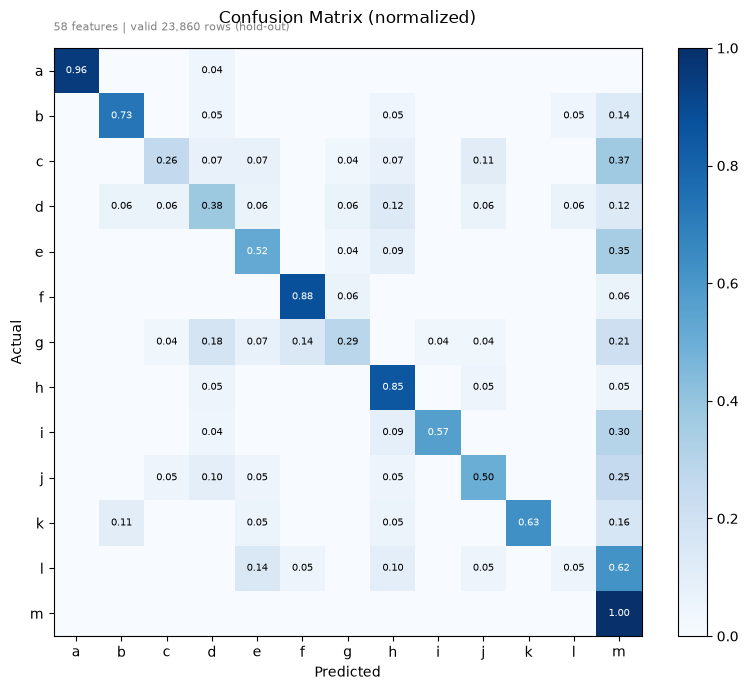


[③ 혼동행렬 표 (건수)]


,pred_a,pred_b,pred_c,pred_d,pred_e,pred_f,pred_g,pred_h,pred_i,pred_j,pred_k,pred_l,pred_m
actual_a,22,0,0,1,0,0,0,0,0,0,0,0,0
actual_b,0,16,0,1,0,0,0,1,0,0,0,1,3
actual_c,0,0,7,2,2,0,1,2,0,3,0,0,10
actual_d,0,1,1,6,1,0,1,2,0,1,0,1,2
actual_e,0,0,0,0,12,0,1,2,0,0,0,0,8
actual_f,0,0,0,0,0,14,1,0,0,0,0,0,1
actual_g,0,0,1,5,2,4,8,0,1,1,0,0,6
actual_h,0,0,0,1,0,0,0,17,0,1,0,0,1
actual_i,0,0,0,1,0,0,0,2,13,0,0,0,7
actual_j,0,0,1,2,1,0,0,1,0,10,0,0,5


In [ ]:
# ③ 혼동행렬
cm = confusion_matrix(y_va, pred, labels=classes, normalize="true")
cnt = confusion_matrix(y_va, pred, labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (normalized)", pad=18)
ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        if v >= 0.005:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()
_table(pd.DataFrame(cnt, index=[f"actual_{l}" for l in labels],
                    columns=[f"pred_{l}" for l in labels]), "③ 혼동행렬 표 (건수)")

### ④ 임계값별 Macro-F1 — argmax 대신 위험점수로 판정하면

`risk = 1 − P(m)` 이 임계값 이상이면 사기(정상 제외 최고확률 유형)로 본다.
x축은 symlog — 0 근처의 붕괴 구간을 보기 위해서다.


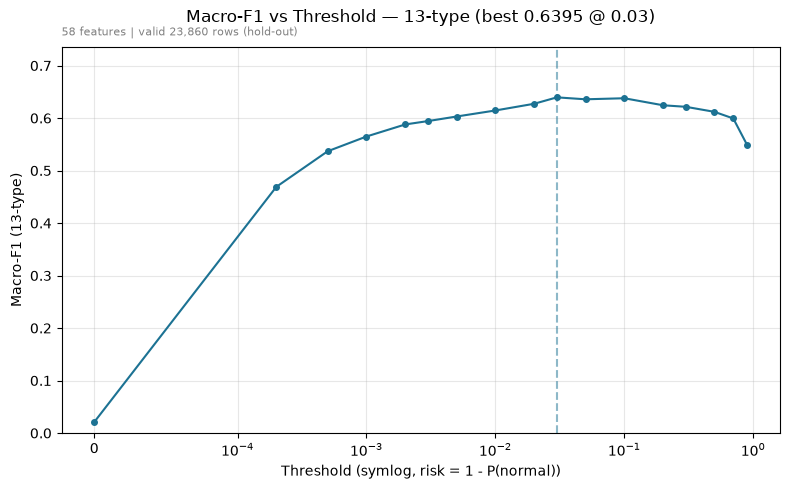


[④ 임계값별 Macro-F1 표 (13유형 분류 기준)]


,임계값,Macro-F1,미탐(FN),오탐(FP)
16,0,0.0210,0,23602
15,0.0002,0.4690,13,389
14,0.0005,0.5368,17,218
13,0.001,0.5649,19,160
12,0.002,0.5879,24,109
11,0.003,0.5943,25,94
10,0.005,0.6030,27,69
9,0.01,0.6145,31,46
8,0.02,0.6273,36,28
7,0.03,0.6395,37,17


  최고점: 임계값 0.03 → Macro-F1 0.6395


In [ ]:
# ④ 임계값별 Macro-F1 (13유형 기준)
sc = thr_scan(THR_FULL).sort_values("thr")
best = sc.loc[sc["macro"].idxmax()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sc["thr"], sc["macro"], "-o", ms=4, color="#1C7293")
ax.set_xscale("symlog", linthresh=1e-4)
ax.axvline(best["thr"], ls="--", color="#1C7293", alpha=.5)
ax.set_xlabel("Threshold (symlog, risk = 1 - P(normal))"); ax.set_ylabel("Macro-F1 (13-type)")
ax.set_ylim(0, max(sc["macro"]) * 1.15); ax.grid(alpha=.3)
ax.set_title(f"Macro-F1 vs Threshold — 13-type (best {best['macro']:.4f} @ {best['thr']:g})", pad=18)
ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
fig.tight_layout(); plt.show()
t = sc[["thr", "macro", "FN", "FP"]].copy()
t["thr"] = t["thr"].map(lambda v: f"{v:g}")
t = t.rename(columns={"thr": "임계값", "macro": "Macro-F1", "FN": "미탐(FN)", "FP": "오탐(FP)"})
_table(t, "④ 임계값별 Macro-F1 표 (13유형 분류 기준)")
print(f"  최고점: 임계값 {best['thr']:g} → Macro-F1 {best['macro']:.4f}")